### Content: 
Given the presence of ID identifying the vehicles in the `tripsv3_cleaned.parquet` dataset, one can study how each e-scooter is used; for instance, one can check the cumulative time of usage of each vehicle and if there are patterns in the trajectory a given e-scooter does, which may suggest it is underused.

In [124]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import contextily as ctx
import matplotlib.pyplot as plt

In [97]:
data = pd.read_parquet('../data/tripsv3_cleaned.parquet')

In [98]:
data.head(2)

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31


In [99]:
data.trip_origin_longitude = data.trip_origin_longitude.astype(float)
data.trip_origin_latitude = data.trip_origin_latitude.astype(float)
data.trip_destination_latitude = data.trip_destination_latitude.astype(float)
data.trip_destination_longitude = data.trip_destination_longitude.astype(float)

In [100]:
len(data.trip_vehicle_id.unique()) # 645 different scooters available 

645

In [101]:
len(data[data.operator=='BIT'].trip_vehicle_id.unique()), len(data[data.operator=='VENTO'].trip_vehicle_id.unique())
# 320 e-scooters by BIT and 325 by Vento

(320, 325)

### Cumulative time of usage per e-scooter

In [102]:
duration = []
for r in range(len(data)):
    duration.append(data.trip_end[r]-data.trip_start[r])
data['duration'] = duration

In [103]:
# cumulative run time for each vehicle
drtn_by_v = data.groupby(['trip_vehicle_id'])['duration'].agg(["sum"]).reset_index()
drtn_by_v.columns = ['trip_vehicle_id', 'cumduration']
drtn_by_v.head()

,trip_vehicle_id,cumduration
0,126589,0 days 05:04:04
1,126637,0 days 04:31:09
2,126682,0 days 05:42:20
3,127093,0 days 07:44:29
4,127115,0 days 07:12:42


In [104]:
drtn_by_v['cumduration'].max() # 6 days 12 h 13 min 02 sec

Timedelta('6 days 12:13:02')

In [105]:
drtn_by_v['cumduration'].min() # 6 min 49 sec ?!?!?!?!

Timedelta('0 days 00:06:49')

In [106]:
drtn_by_v[drtn_by_v['cumduration']==drtn_by_v['cumduration'].min()]

,trip_vehicle_id,cumduration
345,3S5078,0 days 00:06:49


In [107]:
drtn_by_v.sort_values(by=['cumduration'])

,trip_vehicle_id,cumduration
345,3S5078,0 days 00:06:49
384,3s140,0 days 00:08:00
263,3S4270,0 days 00:10:23
418,3s2135,0 days 00:13:39
144,158286,0 days 00:19:30
...,...,...
304,3S4675,5 days 03:11:56
478,3s3028,5 days 09:58:19
276,3S4339,6 days 04:42:23
228,3S3971,6 days 05:49:12


In [108]:
drtn_by_v['cumduration'].mean()  
# average usage of an e-scooter (from 2020 to March 2022): 1 day 2 h 23 min 45 sec
# maybe some e-scooters are added later in time, not all made available since the beginning of 2020

Timedelta('1 days 02:23:45.125581395')

In [109]:
### USAGE IN 2022 ONLY
y=[]
for r in range(len(data)):
    y.append(data.trip_start[r].year)
data['year']=y
df = data[data.year == 2022]
# cumulative run time for each vehicle
drtn_by_v2022 = df.groupby(['trip_vehicle_id'])['duration'].agg(["sum"]).reset_index()
drtn_by_v2022.columns = ['trip_vehicle_id', 'cumduration']
drtn_by_v2022.head()

,trip_vehicle_id,cumduration
0,126589,0 days 05:04:04
1,126637,0 days 04:31:09
2,126682,0 days 05:42:20
3,127093,0 days 07:44:29
4,127115,0 days 07:12:42


In [110]:
print('Minimum:',drtn_by_v2022['cumduration'].min(), 
    '\nMaximum:', drtn_by_v2022['cumduration'].max(), 
    '\nMean:', drtn_by_v2022['cumduration'].mean(), 
    '\nMedian:', drtn_by_v2022['cumduration'].median())

Minimum: 0 days 00:02:09 
Maximum: 2 days 03:41:04 
Mean: 0 days 12:14:27.049853372 
Median: 0 days 07:20:39


In [111]:
less_one_day = drtn_by_v[drtn_by_v.cumduration < pd.Timedelta('1 days 00:00:00')].trip_vehicle_id.to_list()

In [112]:
t=[]
for id in range(len(data.trip_vehicle_id)):
    if data.trip_vehicle_id[id] in less_one_day:
        t.append(data.trip_start[id])


In [113]:
t.sort()
t # some of the vehicles with lowest usage (less than 24 hours over their lifetime) were in use already in 2020

[Timestamp('2020-11-30 15:42:50+0000', tz='UTC'),
 Timestamp('2020-11-30 16:04:42+0000', tz='UTC'),
 Timestamp('2020-11-30 16:35:56+0000', tz='UTC'),
 Timestamp('2020-11-30 17:04:43+0000', tz='UTC'),
 Timestamp('2020-11-30 21:34:30+0000', tz='UTC'),
 Timestamp('2020-12-01 08:53:54+0000', tz='UTC'),
 Timestamp('2020-12-01 09:13:40+0000', tz='UTC'),
 Timestamp('2020-12-01 09:56:24+0000', tz='UTC'),
 Timestamp('2020-12-01 10:33:38+0000', tz='UTC'),
 Timestamp('2020-12-01 13:13:11+0000', tz='UTC'),
 Timestamp('2020-12-01 13:14:51+0000', tz='UTC'),
 Timestamp('2020-12-01 14:02:15+0000', tz='UTC'),
 Timestamp('2020-12-01 15:07:13+0000', tz='UTC'),
 Timestamp('2020-12-01 16:18:46+0000', tz='UTC'),
 Timestamp('2020-12-01 17:16:05+0000', tz='UTC'),
 Timestamp('2020-12-01 18:47:12+0000', tz='UTC'),
 Timestamp('2020-12-01 19:46:45+0000', tz='UTC'),
 Timestamp('2020-12-01 20:35:25+0000', tz='UTC'),
 Timestamp('2020-12-01 20:38:57+0000', tz='UTC'),
 Timestamp('2020-12-01 22:45:12+0000', tz='UTC'),


### Areas of usage:

Geohashing using `python-geohash` library ([reference](https://stackoverflow.com/questions/49467932/dividing-city-by-longitude-and-latitude-into-matrix) & [demo](http://www.movable-type.co.uk/scripts/geohash.html)).

The goal is to map a cell identifier to the list of points inside that cell.
Thus points beloniging to the same cell (which width and height are defined in the addToGeohash, getFromGeohash and getGeohash functions, using the precision parameter) are mapped to the same digest.

In [165]:
from geohash import encode

precision = 6
# precision & len of the hash 
# 7 means ≤ cell width 153m × cell height 153m --> in our case, produce over 600 cells
# 6	≤ 1.22km × 0.61km --> in our case, produce 40 cells
# maggiore la precisione, più piccola l'estensione della cella nella grid

def addToGeohash(m, latitude, longitude):
    '''
    Add point to the identifier of its cell
    '''
    p = (latitude, longitude)
    ph = encode(p[0], p[1], precision)  
    if ph not in m:
        m[ph] = []
    m[ph].append(p)
    return


def getFromGeohash(m, latitude, longitude):
    '''
    Get list of the points belonging to the same cell of the passed pt 
    '''
    p = (latitude, longitude)
    ph = encode(p[0], p[1], precision)
    print ("query hash: " + ph)
    if ph in m:
        return m[ph]
    return []


def getGeohash(m, latitude, longitude):
    '''
    Get geohash identifying the cell 
    '''
    p = (latitude, longitude)
    ph = encode(p[0], p[1], precision)
    if ph in m:
        return ph
    raise ValueError('Not found')

In [172]:
# create empty map
m = dict()

# add points of origin trip to the mapping m, so that they are groupped by block
# add also a column with cell of belonging to the dataframe
# do the same with points of destination
gh_origin=[]
gh_destination=[]

for pt in range(len(data)):
    addToGeohash(m, data.trip_origin_latitude[pt], data.trip_origin_longitude[pt])
    addToGeohash(m, data.trip_destination_latitude[pt], data.trip_destination_longitude[pt])
    gh_origin.append(getGeohash(m, data.trip_origin_latitude[pt], data.trip_origin_longitude[pt]))
    gh_destination.append(getGeohash(m, data.trip_destination_latitude[pt], data.trip_destination_longitude[pt]))

data['geohash_origin'] = gh_origin
data['geohash_destination'] = gh_destination

print("Length of hashmap/number of blocks in the grid: "+str(len(m.keys())))
print("Number of blocks for origin trips: ", len(data.geohash_origin.unique()))
print("Number of blocks for destination trips: ", len(data.geohash_destination.unique()))
# print("Contents of map: "+str(m))

Length of hashmap/number of blocks in the grid: 58
Number of blocks for origin trips:  40
Number of blocks for destination trips:  58


In [170]:
data.geohash_origin.value_counts()

u0pyj4    28760
u0pyj1    12931
u0pyj5    10917
u0pyj0     7865
u0pyhc     5945
u0pyhf     5755
u0pyjh     3773
u0pyhb     3357
u0pyj2     2759
u0pyj3     2508
u0pvvq     2465
u0pyjj     2462
u0pvvp     2292
u0pyhy     2261
u0pyhu     1873
u0pvvr     1764
u0pyhg     1678
u0pyjn     1367
u0pvvn     1230
u0pvuz      913
u0pyhv      904
u0pyhz      779
u0pyj6      770
u0pvvk      636
u0pyhx      375
u0pyjp      358
u0pykb      292
u0pvvj      281
u0pvvm      275
u0pykc      162
u0pyhw      146
u0pyk8      139
u0pym0       63
u0pvvh       31
u0pvv7       29
u0pvuy       12
u0pyk9        7
u0pykf        5
u0pvvt        1
u0pyht        1
Name: geohash_origin, dtype: int64

In [150]:
data = gpd.GeoDataFrame(data, crs='EPSG:4326', geometry=gpd.points_from_xy(data.trip_origin_longitude, data.trip_origin_latitude))

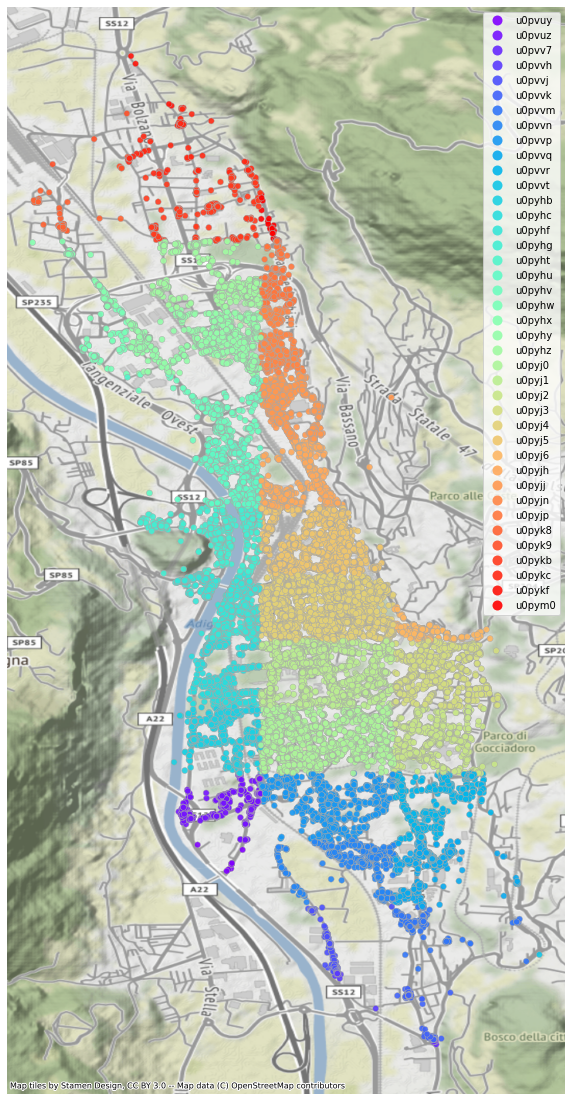

In [162]:
fig, ax = plt.subplots(1, figsize=(25,20)) 

data.to_crs(epsg=4326).plot(column="geohash",
                    alpha=.9, cmap="rainbow", edgecolor = "darkgrey", 
                    legend=True, linewidth = 0.5,     
                    ax=ax)

ctx.add_basemap(ax, crs=data.to_crs(epsg=4326).crs.to_string())

ax.set_axis_off()

In [173]:
data

,operator,trip_vehicle_id,trip_start,trip_end,trip_duration_break_excluded,trip_origin_latitude,trip_origin_longitude,trip_destination_latitude,trip_destination_longitude,trip_length,trip_accuracy,unique_id,duration,year,geohash,geometry,geohash_origin,geohash_destination
0,BIT,3s1958,2021-12-31 22:51:07+00:00,2021-12-31 23:05:16+00:00,14.150000,46.069058,11.125847,46.069185,11.125873,2420.000000,15.0,00000f26-0000-1000-85d6-5b7d6a617b60_2021-12-31,0 days 00:14:09,2021,u0pyj4,POINT (11.12585 46.06906),u0pyj4,u0pyj4
1,BIT,3s2628,2021-12-31 22:52:32+00:00,2021-12-31 23:05:22+00:00,12.816667,46.069980,11.123846,46.069166,11.125992,2290.000000,15.0,00000f55-0000-1000-85f5-5b7d6a617b60_2021-12-31,0 days 00:12:50,2021,u0pyj4,POINT (11.12385 46.06998),u0pyj4,u0pyj4
2,BIT,3S4007,2021-12-31 23:32:46+00:00,2021-12-31 23:34:37+00:00,1.850000,46.064904,11.123108,46.064540,11.120380,210.000000,15.0,00002677-0000-1000-9537-5b7d6a617b60_2021-12-31,0 days 00:01:51,2021,u0pyj1,POINT (11.12311 46.06490),u0pyj1,u0pyj1
3,BIT,3s2628,2021-12-31 23:26:03+00:00,2021-12-31 23:37:03+00:00,11.000000,46.069138,11.125999,46.067448,11.124116,950.000000,15.0,000002e4-0000-1000-9784-5b7d6a617b60_2021-12-31,0 days 00:11:00,2021,u0pyj4,POINT (11.12600 46.06914),u0pyj4,u0pyj4
4,BIT,3s1958,2021-12-31 23:26:22+00:00,2021-12-31 23:45:04+00:00,18.700000,46.069156,11.125829,46.069609,11.125088,1900.000000,15.0,0000101c-0000-1000-a03c-5b7d6a617b60_2021-12-31,0 days 00:18:42,2021,u0pyj4,POINT (11.12583 46.06916),u0pyj4,u0pyj4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108136,BIT,3s2603,2022-05-04 22:18:13+00:00,2022-05-04 22:22:55+00:00,4.683333,46.066114,11.131366,46.069898,11.119706,1240.000000,15.0,0000231d-0000-1000-818d-5b7d6a617b60_2022-05-04,0 days 00:04:42,2022,u0pyj6,POINT (11.13137 46.06611),u0pyj6,u0pyj4
108137,BIT,3s170,2022-05-04 22:10:13+00:00,2022-05-04 22:31:08+00:00,20.916667,46.068879,11.125948,46.057510,11.125230,3350.000000,15.0,00000bd7-0000-1000-8bf7-5b7d6a617b60_2022-05-04,0 days 00:20:55,2022,u0pyj4,POINT (11.12595 46.06888),u0pyj4,u0pyj0
108138,BIT,3s2644,2022-05-04 22:05:28+00:00,2022-05-04 22:12:03+00:00,6.566667,46.069549,11.119470,46.061051,11.124934,1150.000000,15.0,00000ce6-0000-1000-99f6-5b7d6a617b60_2022-05-04,0 days 00:06:35,2022,u0pyj4,POINT (11.11947 46.06955),u0pyj4,u0pyj1
108139,BIT,3s3025,2022-05-04 22:51:02+00:00,2022-05-04 22:53:26+00:00,2.383333,46.066806,11.120345,46.061369,11.118962,670.000000,15.0,00000341-0000-1000-a011-5b7d6a617b60_2022-05-04,0 days 00:02:24,2022,u0pyj4,POINT (11.12035 46.06681),u0pyj4,u0pyj1


In [175]:
# crosstab between vehicle IDs and area of origin of the trip
# if an ID present often (wrt the total number of times it is used)
# the same area of origin there may be some pattern to check
cols = ['trip_vehicle_id', 'geohash_origin']
colmap = sns.light_palette("green", as_cmap=True)
pd.crosstab(data[cols[0]], data[cols[1]]).style.background_gradient(cmap = colmap)

In [187]:
zones = data.geohash_origin.value_counts().to_frame()
zones = zones.reset_index()
zones = zones.rename(columns={"index": "geohash_origin", "geohash_origin": "freq"})
zones

,geohash_origin,freq
0,u0pyj4,28760
1,u0pyj1,12931
2,u0pyj5,10917
3,u0pyj0,7865
4,u0pyhc,5945
5,u0pyhf,5755
6,u0pyjh,3773
7,u0pyhb,3357
8,u0pyj2,2759
9,u0pyj3,2508
